In [10]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
pd.set_option('display.max_columns', None)

In [12]:
kwh_data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Raw Data/Kwh_Data_Model_Train.csv", index_col= 'datetime', parse_dates= True)
kwh_data

,temp1,humidity1,windgust1,winddir1,cloudcover1,solarradiation1,temp2,humidity2,windgust2,winddir2,cloudcover2,solarradiation2,temp3,humidity3,windgust3,winddir3,cloudcover3,solarradiation3,temp4,humidity4,windgust4,winddir4,cloudcover4,solarradiation4,temp5,humidity5,windgust5,winddir5,cloudcover5,solarradiation5,conditions_int_1,conditions_int_2,conditions_int_3,conditions_int_4,conditions_int_5,Kwh
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,6.0,75.51,19.8,240.0,0.0,0.0,5.7,80.47,17.3,240.0,0.0,0.0,6.0,75.52,21.2,240.0,0.9,0.0,5.7,78.31,20.2,240.0,0.0,0.0,5.5,84.34,21.6,240.0,0.0,0.0,0,0,0,0,0,0.0000
2022-01-01 01:00:00,6.0,75.51,19.8,298.1,0.0,0.0,6.0,78.82,18.0,261.9,0.0,0.0,6.0,75.52,21.6,309.1,1.7,0.0,5.7,79.77,19.8,291.7,0.0,0.0,5.0,84.28,21.2,311.1,0.0,0.0,0,0,0,0,0,0.0000
2022-01-01 02:00:00,4.9,81.61,20.5,301.0,40.9,0.0,5.6,82.35,18.9,333.0,40.0,0.0,2.3,89.61,16.2,2.0,0.0,0.0,4.3,82.60,16.0,305.0,0.0,0.0,3.8,89.49,11.8,305.0,30.0,0.0,2,2,0,0,2,0.0000
2022-01-01 03:00:00,4.0,80.80,20.5,294.8,38.0,0.0,4.3,82.60,18.7,90.0,17.8,0.0,4.0,80.80,21.2,296.4,27.3,0.0,3.2,85.34,20.5,0.0,0.0,0.0,3.5,90.35,22.3,311.0,0.0,0.0,2,0,2,0,0,0.0000
2022-01-01 04:00:00,3.0,93.14,19.8,292.3,41.7,0.0,3.3,93.16,18.7,90.0,19.6,0.0,3.0,93.14,20.2,294.0,28.1,0.0,2.5,94.85,19.8,286.3,0.0,0.0,2.5,93.11,22.3,306.5,0.0,0.0,2,0,2,0,0,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,41.15,22.0,180.0,79.3,207.0,25.7,42.86,17.6,290.0,27.5,207.0,23.1,42.02,32.4,313.0,50.0,207.0,23.7,45.57,23.4,170.0,50.0,39.0,23.5,57.88,20.9,180.0,50.0,121.0,2,2,2,2,2,0.0592
2024-07-04 20:00:00,23.0,40.87,22.0,172.8,81.7,103.0,24.4,45.20,15.8,209.0,27.5,103.0,22.1,43.60,26.3,30.0,50.0,103.0,22.0,50.00,16.6,140.0,89.0,82.0,23.0,55.83,17.3,170.2,50.0,71.0,5,2,2,2,2,0.0085
2024-07-04 21:00:00,21.0,49.39,14.4,0.0,63.7,9.0,22.4,50.62,5.0,304.0,30.0,9.0,21.8,48.00,17.6,42.0,66.6,9.0,21.3,52.10,5.4,356.0,41.7,51.0,22.1,58.99,15.1,0.0,50.0,44.0,5,2,2,5,2,0.0000


In [13]:
kwh_data['Kwh Target'] = kwh_data['Kwh']
kwh_data.head(30)

,temp1,humidity1,windgust1,winddir1,cloudcover1,solarradiation1,temp2,humidity2,windgust2,winddir2,cloudcover2,solarradiation2,temp3,humidity3,windgust3,winddir3,cloudcover3,solarradiation3,temp4,humidity4,windgust4,winddir4,cloudcover4,solarradiation4,temp5,humidity5,windgust5,winddir5,cloudcover5,solarradiation5,conditions_int_1,conditions_int_2,conditions_int_3,conditions_int_4,conditions_int_5,Kwh,Kwh Target
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,6.0,75.51,19.8,240.0,0.0,0.0,5.7,80.47,17.3,240.0,0.0,0.0,6.0,75.52,21.2,240.0,0.9,0.0,5.7,78.31,20.2,240.0,0.0,0.0,5.5,84.34,21.6,240.0,0.0,0.0,0,0,0,0,0,0.0000,0.0000
2022-01-01 01:00:00,6.0,75.51,19.8,298.1,0.0,0.0,6.0,78.82,18.0,261.9,0.0,0.0,6.0,75.52,21.6,309.1,1.7,0.0,5.7,79.77,19.8,291.7,0.0,0.0,5.0,84.28,21.2,311.1,0.0,0.0,0,0,0,0,0,0.0000,0.0000
2022-01-01 02:00:00,4.9,81.61,20.5,301.0,40.9,0.0,5.6,82.35,18.9,333.0,40.0,0.0,2.3,89.61,16.2,2.0,0.0,0.0,4.3,82.60,16.0,305.0,0.0,0.0,3.8,89.49,11.8,305.0,30.0,0.0,2,2,0,0,2,0.0000,0.0000
2022-01-01 03:00:00,4.0,80.80,20.5,294.8,38.0,0.0,4.3,82.60,18.7,90.0,17.8,0.0,4.0,80.80,21.2,296.4,27.3,0.0,3.2,85.34,20.5,0.0,0.0,0.0,3.5,90.35,22.3,311.0,0.0,0.0,2,0,2,0,0,0.0000,0.0000
2022-01-01 04:00:00,3.0,93.14,19.8,292.3,41.7,0.0,3.3,93.16,18.7,90.0,19.6,0.0,3.0,93.14,20.2,294.0,28.1,0.0,2.5,94.85,19.8,286.3,0.0,0.0,2.5,93.11,22.3,306.5,0.0,0.0,2,0,2,0,0,0.0000,0.0000
2022-01-01 05:00:00,3.0,93.11,19.6,296.0,39.6,0.0,4.7,85.36,36.1,270.0,18.6,0.0,-1.1,99.99,7.6,301.0,0.0,0.0,2.1,92.63,11.7,321.0,0.0,0.0,2.5,93.11,22.7,306.8,0.1,0.0,2,0,0,0,0,0.0000,0.0000
2022-01-01 06:00:00,4.0,86.80,20.9,360.0,44.7,0.0,4.0,88.68,19.1,360.0,19.8,0.0,4.0,86.80,20.9,360.0,100.0,0.0,3.0,88.33,19.8,360.0,0.6,0.0,3.0,93.44,23.8,360.0,0.6,0.0,2,0,1,0,0,0.0000,0.0000
2022-01-01 07:00:00,6.0,75.51,22.3,340.0,63.9,0.0,5.4,78.73,20.2,340.0,49.3,0.0,6.0,75.52,22.0,340.0,100.0,0.0,4.7,81.10,21.6,343.0,13.1,0.0,3.9,87.36,25.9,340.0,8.3,0.0,2,2,1,0,0,0.0000,0.0000
2022-01-01 08:00:00,5.0,80.95,22.3,340.0,49.9,6.0,5.6,80.29,20.5,323.0,46.5,6.0,-1.1,99.99,21.6,274.0,52.6,6.0,3.1,86.52,21.6,349.0,36.9,0.0,2.4,90.27,27.0,340.0,50.0,0.1,2,2,2,2,2,0.0305,0.0305


In [14]:
scaler = StandardScaler()
df_scaled_kwh = scaler.fit_transform(kwh_data.iloc[:, :kwh_data.shape[1] - 1])
df_scaled_kwh = pd.DataFrame(df_scaled_kwh)
df_scaled_kwh.head(20)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35
0,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640,-1.009887,0.853544,0.160899,0.243452,-1.414670,-0.710077,-0.732571,0.430338,-0.062316,0.257627,-1.415610,-0.667396,-0.893320,0.738504,0.298943,0.336897,-1.369232,-0.702416,-1.037464,0.926566,0.449868,0.513351,-1.439209,-0.706979,-1.128321,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890
1,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640,-0.974958,0.773497,0.228552,0.417484,-1.414670,-0.710077,-0.732571,0.430338,-0.029096,0.813706,-1.392812,-0.667396,-0.893320,0.806940,0.260969,0.717556,-1.369232,-0.702416,-1.093388,0.923848,0.409202,1.028030,-1.439209,-0.706979,-1.128321,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890
2,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640,-1.021530,0.944749,0.315535,0.982490,0.023965,-0.710077,-1.152691,1.100690,-0.477562,-1.657667,-1.441258,-0.667396,-1.054518,0.939595,-0.099781,0.815481,-1.369232,-0.702416,-1.227605,1.159931,-0.546449,0.983873,-0.473644,-0.706979,0.662831,0.249815,-1.367889,-1.277920,0.377153,-0.679890
3,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640,-1.172888,0.956878,0.296205,-0.948545,-0.774477,-0.710077,-0.959663,0.681542,-0.062316,0.711503,-0.663277,-0.667396,-1.181174,1.068031,0.327423,-1.430185,-1.369232,-0.702416,-1.261160,1.198900,0.521034,1.027306,-1.439209,-0.706979,0.662831,-1.736325,0.540307,-1.277920,-1.776342,-0.679890
4,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640,-1.289318,1.469178,0.296205,-0.948545,-0.709739,-0.710077,-1.073209,1.268635,-0.145365,0.692190,-0.640479,-0.667396,-1.261773,1.513807,0.260969,0.677796,-1.369232,-0.702416,-1.373008,1.323965,0.521034,0.994731,-1.439209,-0.706979,0.662831,-1.736325,0.540307,-1.277920,-1.776342,-0.679890
5,-1.186254,1.457328,0.380872,0.574686,-0.209547,-0.667640,-1.126316,1.090774,1.977864,0.481851,-0.745705,-0.710077,-1.538748,1.594533,-1.191786,0.748522,-1.441258,-0.667396,-1.307829,1.409746,-0.507998,0.933287,-1.369232,-0.702416,-1.373008,1.323965,0.561700,0.996903,-1.435991,-0.706979,0.662831,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890
6,-1.072353,1.177858,0.520352,1.045183,-0.078226,-0.667640,-1.207817,1.251839,0.334864,1.197050,-0.702546,-0.710077,-0.959663,0.967000,-0.087230,1.223322,1.408488,-0.667396,-1.204202,1.208186,0.260969,1.220438,-1.352558,-0.702416,-1.317084,1.338919,0.673532,1.382007,-1.419898,-0.706979,0.662831,-1.736325,-0.413791,-1.277920,-1.776342,-0.679890
7,-0.844550,0.677822,0.670561,0.898152,0.416156,-0.667640,-1.044816,0.769131,0.441176,1.038117,0.358448,-0.710077,-0.732571,0.430338,0.004124,1.062372,1.408488,-0.667396,-1.008462,0.869283,0.431851,1.095269,-1.005189,-0.702416,-1.216421,1.063413,0.887028,1.237231,-1.172070,-0.706979,0.662831,0.249815,-0.413791,-1.277920,-1.776342,-0.679890
8,-0.958452,0.918760,0.670561,0.898152,0.055669,-0.644949,-1.021530,0.844812,0.470170,0.903024,0.257744,-0.687358,-1.538748,1.594533,-0.029096,0.531241,0.057708,-0.644689,-1.192688,1.123343,0.431851,1.139446,-0.343797,-0.702416,-1.384192,1.195275,0.998860,1.237231,0.170066,-0.706621,0.662831,0.249815,0.540307,0.467173,0.377153,-0.542965
9,-0.844550,0.924518,0.745665,0.530576,0.058244,-0.580657,-1.009887,1.139773,0.682794,0.259345,0.139056,-0.622989,-1.039145,0.936551,0.211747,0.660000,-0.016385,-0.580352,-1.008462,1.075531,0.564759,0.778667,-0.140933,-0.543868,-1.216421,1.200260,1.181857,0.875291,0.170066,-0.516372,0.662831,0.249815,0.540307,0.467173,0.377153,-0.234996


In [15]:
df_scaled_kwh.index = kwh_data.index
df_scaled_kwh

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640,-1.009887,0.853544,0.160899,0.243452,-1.414670,-0.710077,-0.732571,0.430338,-0.062316,0.257627,-1.415610,-0.667396,-0.893320,0.738504,0.298943,0.336897,-1.369232,-0.702416,-1.037464,0.926566,0.449868,0.513351,-1.439209,-0.706979,-1.128321,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890
2022-01-01 01:00:00,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640,-0.974958,0.773497,0.228552,0.417484,-1.414670,-0.710077,-0.732571,0.430338,-0.029096,0.813706,-1.392812,-0.667396,-0.893320,0.806940,0.260969,0.717556,-1.369232,-0.702416,-1.093388,0.923848,0.409202,1.028030,-1.439209,-0.706979,-1.128321,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890
2022-01-01 02:00:00,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640,-1.021530,0.944749,0.315535,0.982490,0.023965,-0.710077,-1.152691,1.100690,-0.477562,-1.657667,-1.441258,-0.667396,-1.054518,0.939595,-0.099781,0.815481,-1.369232,-0.702416,-1.227605,1.159931,-0.546449,0.983873,-0.473644,-0.706979,0.662831,0.249815,-1.367889,-1.277920,0.377153,-0.679890
2022-01-01 03:00:00,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640,-1.172888,0.956878,0.296205,-0.948545,-0.774477,-0.710077,-0.959663,0.681542,-0.062316,0.711503,-0.663277,-0.667396,-1.181174,1.068031,0.327423,-1.430185,-1.369232,-0.702416,-1.261160,1.198900,0.521034,1.027306,-1.439209,-0.706979,0.662831,-1.736325,0.540307,-1.277920,-1.776342,-0.679890
2022-01-01 04:00:00,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640,-1.289318,1.469178,0.296205,-0.948545,-0.709739,-0.710077,-1.073209,1.268635,-0.145365,0.692190,-0.640479,-0.667396,-1.261773,1.513807,0.260969,0.677796,-1.369232,-0.702416,-1.373008,1.323965,0.521034,0.994731,-1.439209,-0.706979,0.662831,-1.736325,0.540307,-1.277920,-1.776342,-0.679890
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,1.205675,-0.843987,0.638373,-0.278091,0.812692,0.115206,1.318702,-0.971041,0.189893,0.640784,-0.425608,0.073713,1.209067,-1.163471,0.867837,0.845091,-0.016385,0.116002,1.179227,-0.796165,0.602733,-0.178502,0.020247,-0.567112,0.975798,-0.272428,0.378703,0.079023,0.170066,-0.274270,0.662831,0.249815,0.540307,0.467173,0.377153,-0.414121
2024-07-04 20:00:00,1.091774,-0.856388,0.638373,-0.331022,0.874490,-0.278108,1.167343,-0.857520,0.015929,-0.002894,-0.425608,-0.320075,1.095521,-1.088301,0.361236,-1.432338,-0.016385,-0.277590,0.983486,-0.588512,-0.042820,-0.399388,1.104041,-0.417931,0.919874,-0.365320,0.012709,0.008083,0.170066,-0.453075,3.349560,0.249815,0.540307,0.467173,0.377153,-0.641731
2024-07-04 21:00:00,0.863971,-0.479036,-0.177047,-1.601364,0.411006,-0.633603,0.934485,-0.594578,-1.027860,0.752037,-0.335694,-0.675999,1.061457,-0.878964,-0.361293,-1.335769,0.456673,-0.633336,0.902887,-0.490075,-1.106084,1.190986,-0.210407,-0.525480,0.819211,-0.222130,-0.210954,-1.223961,0.170066,-0.549630,3.349560,0.249815,0.540307,3.084813,0.377153,-0.679890


In [16]:
df_scaled_kwh = pd.concat([df_scaled_kwh, kwh_data["Kwh Target"]], axis=1)
df_scaled_kwh.head(30)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,Kwh Target
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640,-1.009887,0.853544,0.160899,0.243452,-1.414670,-0.710077,-0.732571,0.430338,-0.062316,0.257627,-1.415610,-0.667396,-0.893320,0.738504,0.298943,0.336897,-1.369232,-0.702416,-1.037464,0.926566,0.449868,0.513351,-1.439209,-0.706979,-1.128321,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890,0.0000
2022-01-01 01:00:00,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640,-0.974958,0.773497,0.228552,0.417484,-1.414670,-0.710077,-0.732571,0.430338,-0.029096,0.813706,-1.392812,-0.667396,-0.893320,0.806940,0.260969,0.717556,-1.369232,-0.702416,-1.093388,0.923848,0.409202,1.028030,-1.439209,-0.706979,-1.128321,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890,0.0000
2022-01-01 02:00:00,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640,-1.021530,0.944749,0.315535,0.982490,0.023965,-0.710077,-1.152691,1.100690,-0.477562,-1.657667,-1.441258,-0.667396,-1.054518,0.939595,-0.099781,0.815481,-1.369232,-0.702416,-1.227605,1.159931,-0.546449,0.983873,-0.473644,-0.706979,0.662831,0.249815,-1.367889,-1.277920,0.377153,-0.679890,0.0000
2022-01-01 03:00:00,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640,-1.172888,0.956878,0.296205,-0.948545,-0.774477,-0.710077,-0.959663,0.681542,-0.062316,0.711503,-0.663277,-0.667396,-1.181174,1.068031,0.327423,-1.430185,-1.369232,-0.702416,-1.261160,1.198900,0.521034,1.027306,-1.439209,-0.706979,0.662831,-1.736325,0.540307,-1.277920,-1.776342,-0.679890,0.0000
2022-01-01 04:00:00,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640,-1.289318,1.469178,0.296205,-0.948545,-0.709739,-0.710077,-1.073209,1.268635,-0.145365,0.692190,-0.640479,-0.667396,-1.261773,1.513807,0.260969,0.677796,-1.369232,-0.702416,-1.373008,1.323965,0.521034,0.994731,-1.439209,-0.706979,0.662831,-1.736325,0.540307,-1.277920,-1.776342,-0.679890,0.0000
2022-01-01 05:00:00,-1.186254,1.457328,0.380872,0.574686,-0.209547,-0.667640,-1.126316,1.090774,1.977864,0.481851,-0.745705,-0.710077,-1.538748,1.594533,-1.191786,0.748522,-1.441258,-0.667396,-1.307829,1.409746,-0.507998,0.933287,-1.369232,-0.702416,-1.373008,1.323965,0.561700,0.996903,-1.435991,-0.706979,0.662831,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890,0.0000
2022-01-01 06:00:00,-1.072353,1.177858,0.520352,1.045183,-0.078226,-0.667640,-1.207817,1.251839,0.334864,1.197050,-0.702546,-0.710077,-0.959663,0.967000,-0.087230,1.223322,1.408488,-0.667396,-1.204202,1.208186,0.260969,1.220438,-1.352558,-0.702416,-1.317084,1.338919,0.673532,1.382007,-1.419898,-0.706979,0.662831,-1.736325,-0.413791,-1.277920,-1.776342,-0.679890,0.0000
2022-01-01 07:00:00,-0.844550,0.677822,0.670561,0.898152,0.416156,-0.667640,-1.044816,0.769131,0.441176,1.038117,0.358448,-0.710077,-0.732571,0.430338,0.004124,1.062372,1.408488,-0.667396,-1.008462,0.869283,0.431851,1.095269,-1.005189,-0.702416,-1.216421,1.063413,0.887028,1.237231,-1.172070,-0.706979,0.662831,0.249815,-0.413791,-1.277920,-1.776342,-0.679890,0.0000
2022-01-01 08:00:00,-0.958452,0.918760,0.670561,0.898152,0.055669,-0.644949,-1.021530,0.844812,0.470170,0.903024,0.257744,-0.687358,-1.538748,1.594533,-0.029096,0.531241,0.057708,-0.644689,-1.192688,1.123343,0.431851,1.139446,-0.343797,-0.702416,-1.384192,1.195275,0.998860,1.237231,0.170066,-0.706621,0.662831,0.249815,0.540307,0.467173,0.377153,-0.542965,0.0305


In [17]:
def reshape_dataframe_with_target(df, n=5):
    num_columns = len(df.columns) - 1  
    new_columns = [f"{col}{i+1}" for i in range(n) for col in df.columns if col != 'Kwh Target']
    
    reshaped_data = []

    for i in range(len(df) - n):
        new_row = []
        for j in range(n):
            new_row.extend(df.iloc[i + j][df.columns[:-1]].values)  
        new_row.append(df.iloc[i + n]['Kwh Target'])  
        reshaped_data.append(new_row)

    reshaped_df = pd.DataFrame(reshaped_data, columns=new_columns + ['Kwh Target'])
    
    return reshaped_df

reshaped_df = reshape_dataframe_with_target(df_scaled_kwh, n=12)
reshaped_df


,01,11,21,31,41,51,61,71,81,91,101,111,121,131,141,151,161,171,181,191,201,211,221,231,241,251,261,271,281,291,301,311,321,331,341,351,02,12,22,32,42,52,62,72,82,92,102,112,122,132,142,152,162,172,182,192,202,212,222,232,242,252,262,272,282,292,302,312,322,332,342,352,03,13,23,33,43,53,63,73,83,93,103,113,123,133,143,153,163,173,183,193,203,213,223,233,243,253,263,273,283,293,303,313,323,333,343,353,04,14,24,34,44,54,64,74,84,94,104,114,124,134,144,154,164,174,184,194,204,214,224,234,244,254,264,274,284,294,304,314,324,334,344,354,05,15,25,35,45,55,65,75,85,95,105,115,125,135,145,155,165,175,185,195,205,215,225,235,245,255,265,275,285,295,305,315,325,335,345,355,06,16,26,36,46,56,66,76,86,96,106,116,126,136,146,156,166,176,186,196,206,216,226,236,246,256,266,276,286,296,306,316,326,336,346,356,07,17,27,37,47,57,67,77,87,97,107,117,127,137,147,157,167,177,187,197,207,217,227,237,247,257,267,277,287,297,307,317,327,337,347,357,08,18,28,38,48,58,68,78,88,98,108,118,128,138,148,158,168,178,188,198,208,218,228,238,248,258,268,278,288,298,308,318,328,338,348,358,09,19,29,39,49,59,69,79,89,99,109,119,129,139,149,159,169,179,189,199,209,219,229,239,249,259,269,279,289,299,309,319,329,339,349,359,010,110,210,310,410,510,610,710,810,910,1010,1110,1210,1310,1410,1510,1610,1710,1810,1910,2010,2110,2210,2310,2410,2510,2610,2710,2810,2910,3010,3110,3210,3310,3410,3510,011,111,211,311,411,511,611,711,811,911,1011,1111,1211,1311,1411,1511,1611,1711,1811,1911,2011,2111,2211,2311,2411,2511,2611,2711,2811,2911,3011,3111,3211,3311,3411,3511,012,112,212,312,412,512,612,712,812,912,1012,1112,1212,1312,1412,1512,1612,1712,1812,1912,2012,2112,2212,2312,2412,2512,2612,2712,2812,2912,3012,3112,3212,3312,3412,3512,Kwh Target
0,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640,-1.009887,0.853544,0.160899,0.243452,-1.414670,-0.710077,-0.732571,0.430338,-0.062316,0.257627,-1.415610,-0.667396,-0.893320,0.738504,0.298943,0.336897,-1.369232,-0.702416,-1.037464,0.926566,0.449868,0.513351,-1.439209,-0.706979,-1.128321,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640,-0.974958,0.773497,0.228552,0.417484,-1.414670,-0.710077,-0.732571,0.430338,-0.029096,0.813706,-1.392812,-0.667396,-0.893320,0.806940,0.260969,0.717556,-1.369232,-0.702416,-1.093388,0.923848,0.409202,1.028030,-1.439209,-0.706979,-1.128321,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640,-1.021530,0.944749,0.315535,0.982490,0.023965,-0.710077,-1.152691,1.100690,-0.477562,-1.657667,-1.441258,-0.667396,-1.054518,0.939595,-0.099781,0.815481,-1.369232,-0.702416,-1.227605,1.159931,-0.546449,0.983873,-0.473644,-0.706979,0.662831,0.249815,-1.367889,-1.277920,0.377153,-0.679890,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640,-1.172888,0.956878,0.296205,-0.948545,-0.774477,-0.710077,-0.959663,0.681542,-0.062316,0.711503,-0.663277,-0.667396,-1.181174,1.068031,0.327423,-1.430185,-1.369232,-0.702416,-1.261160,1.198900,0.521034,1.027306,-1.439209,-0.706979,0.662831,-1.736325,0.540307,-1.277920,-1.776342,-0.679890,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640,-1.289318,1.469178,0.296205,-0.948545,-0.709739,-0.710077,-1.073209,1.268635,-0.145365,0.692190,-0.640479,-0.667396,-1.261773,1.513807,0.260969,0.677796,-1.369232,-0.702416,-1.373008,1.323965,0.521034,0.994731,-1.439209,-0.706979,0.662831,-1.736325,0.540307,-1.277920,-1.776342,-0.679890,-1.186254,1.457328,0.380872,0.574686,-0.209547,-0.667640,-1.126316,1.090774,1.977864,0.481851,-0.745705,-0.710077,-1.538748,1.594533,-1.191786,0.748522,-1.441258,-0.667396,-1.307829,1.409746,-0.507998,0.933287,-1.369232,-0.702416,-1.373008,1.323965,0.561700,0.996903,-1.435991,-0.706979,0.662831,-1.736325,-1.367889,-1.277920,-1.776342,-0.679890,-1.072353,1.177858,0.520352,1.045183,-0.078226,-0.667640,-1.207817,1.251839,0.334864,1.197050,-0.702546,-0.710077,-0.959663,0.967000,-0.087230,1.223322,1.408488,-0.667396,-1.204202,1.208186,0.2609

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt



x = reshaped_df.drop(columns=['Kwh Target']).values  
y = reshaped_df['Kwh Target'].values  

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, shuffle= False)

x_train.shape, y_train.shape, x_test.shape, y_test.shape

((19773, 432), (19773,), (2198, 432), (2198,))

In [19]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()

x_train = scaler_x.fit_transform(x_train)
y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()

x_test = scaler_x.transform(x_test)
y_test = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

In [12]:
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)

svr_model.fit(x_train, y_train)


SVR()

In [13]:
y_pred = svr_model.predict(x_test)
y_pred

array([ 1.92501832,  2.28344635,  2.5906698 , ..., -0.67048111,
       -0.75551927, -0.73325714])

In [14]:
y_pred = svr_model.predict(x_test)

y_pred = y_pred.reshape(-1, 1)
y_pred = scaler_y.inverse_transform(y_pred)

y_test = y_test.reshape(-1, 1)
y_test = scaler_y.inverse_transform(y_test)

y_pred = y_pred.ravel()
y_test = y_test.ravel()


In [15]:
y_pred = np.where(y_pred< 0 , 0, y_pred)

In [16]:
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2}")

Mean Squared Error: 0.004345887136955366
R² Score: 0.9300679412116737


In [19]:
date_range = pd.date_range(start='2024-04-04 10:00:00', end='2024/7/4 23:00:00', freq='H')
len(date_range)

2198

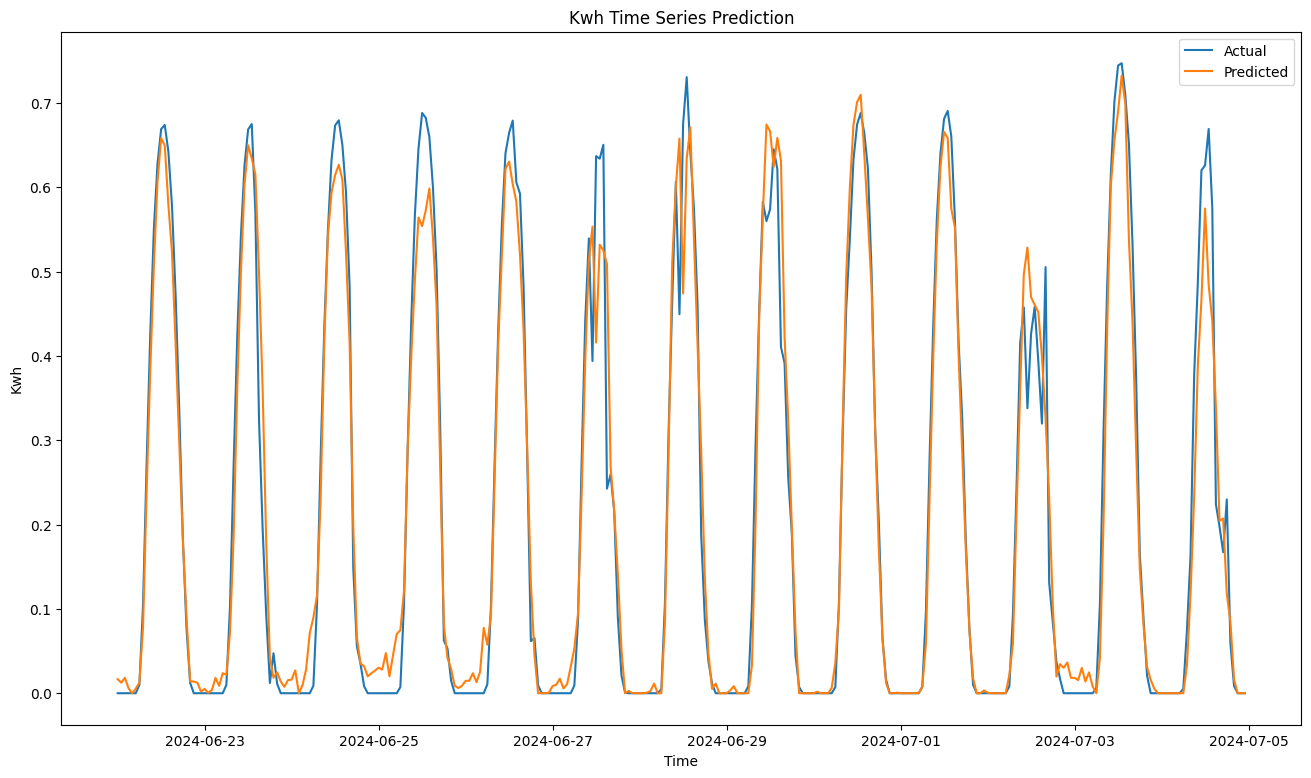

In [20]:
plt.figure(figsize= (16, 9))
sns.lineplot(x = date_range[-312: ], y = y_test[-312:], label='Actual')
sns.lineplot(x = date_range[-312: ], y = y_pred[-312:], label='Predicted')
plt.title('Kwh Time Series Prediction')
plt.xlabel('Time')
plt.ylabel('Kwh')
plt.legend()
plt.show()


# Random Forest

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [20]:
rf_model = RandomForestRegressor()
rf_model.fit(x_train, y_train)

predict_1 = rf_model.predict(x_test)

In [21]:
result_df = pd.DataFrame({"Predictions": predict_1, "Real": y_test})
result_df.head()

,Predictions,Real
0,1.792426,1.689662
1,2.147481,2.340382
2,2.548005,2.591080
3,2.584162,2.596103
4,2.395736,2.420751


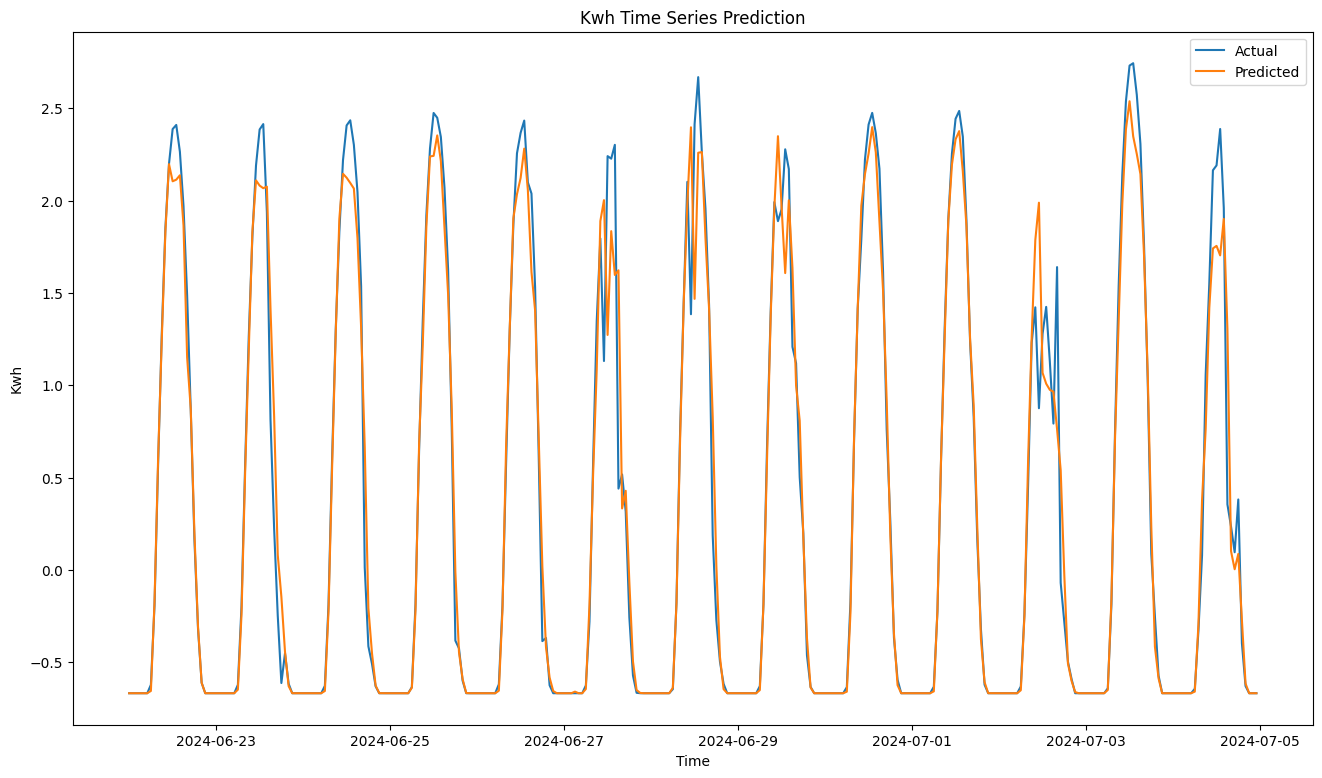

In [23]:
date_range = pd.date_range(start='2024-04-04 10:00:00', end='2024/7/4 23:00:00', freq='H')
len(date_range)

plt.figure(figsize= (16, 9))
sns.lineplot(x = date_range[-312: ], y = y_test[-312:], label='Actual')
sns.lineplot(x = date_range[-312: ], y = predict_1[-312:], label='Predicted')
plt.title('Kwh Time Series Prediction')
plt.xlabel('Time')
plt.ylabel('Kwh')
plt.legend()
plt.show()


In [24]:
mse = mean_squared_error(y_test, predict_1)
print(f"Mean Squared Error: {mse}")

from sklearn.metrics import r2_score
r2 = r2_score(y_test, predict_1)
print(f"R² Score: {r2}")

Mean Squared Error: 0.07912129447364194
R² Score: 0.9389433086008105
